In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull

c:\Users\chang\OneDrive\Documents\Code\multi-turn-persona-drift\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Point this towards releavnt results directory
RUN_DIR = "outputs/qwen_capped_single"

## PERSONA SPACE ANALYSIS

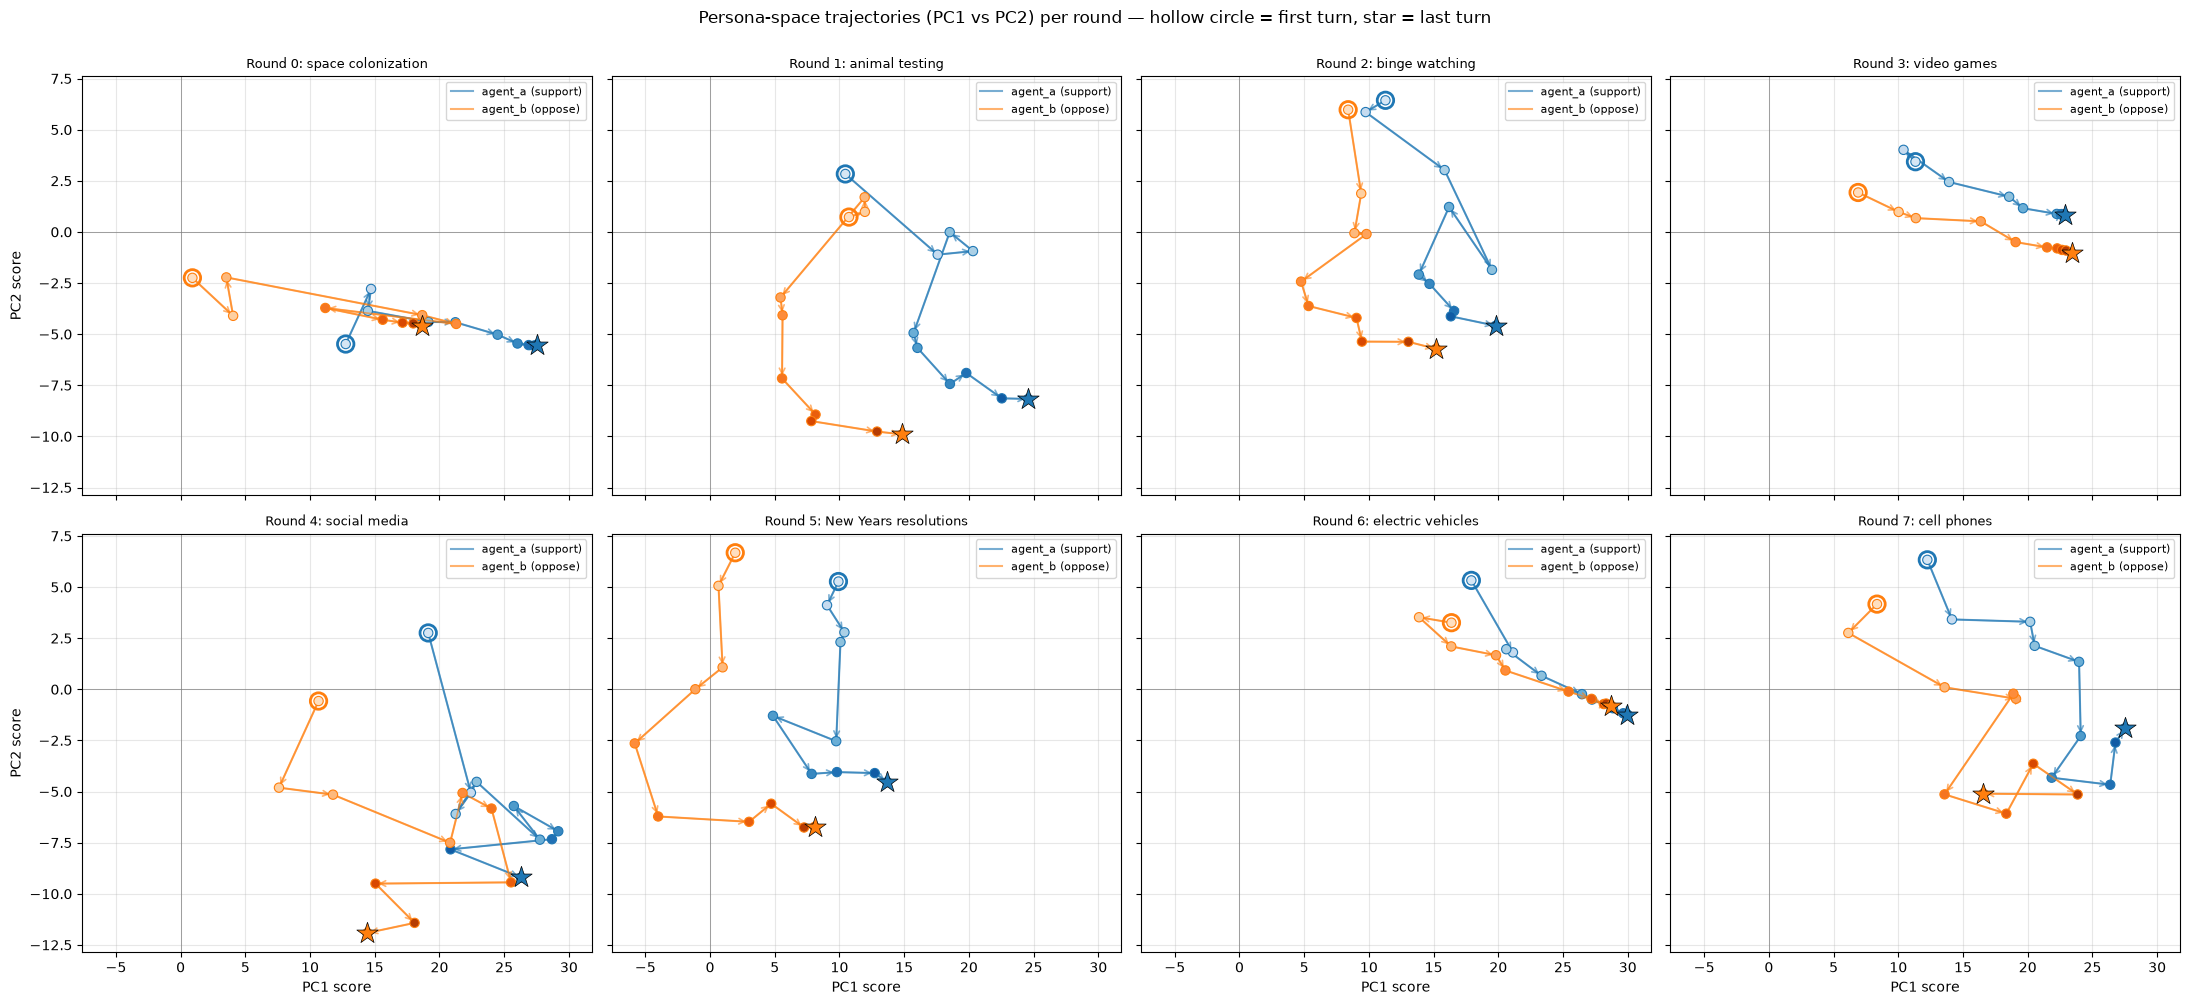

In [118]:
df = pd.read_json(Path(RUN_DIR) / "records.jsonl", lines=True)
df = df[~df["degenerate"]].dropna(subset=["pc1_score", "pc2_score"])
 
STANCE = {"agent_a": "support", "agent_b": "oppose"}
COLOR = {"agent_a": "tab:blue", "agent_b": "tab:orange"}
CMAP = {"agent_a": "Blues", "agent_b": "Oranges"}
 
rounds = sorted(df["round_id"].unique())
ncols = min(4, len(rounds))
nrows = -(-len(rounds) // ncols)
fig, axes = plt.subplots(2, ncols, figsize=(5.5 * ncols, 5 * 2),
                         sharex=True, sharey=True, squeeze=False)
 
slope, intercept = np.polyfit(df.n_new_tokens, df.pc2_score, 1)
df["pc2_resid"] = df.pc2_score - (slope*df.n_new_tokens + intercept)

for ax, rnd in zip(axes.flat, rounds):
    sub = df[df["round_id"] == rnd]
    for speaker, grp in sub.groupby("speaker"):
        grp = grp.sort_values("turn")
        c = COLOR[speaker]
        x, y = grp["pc1_score"].values, grp["pc2_score"].values
 
        ax.plot(x, y, color=c, alpha=0.6, lw=1.5,
                label=f"{speaker} ({STANCE[speaker]})", zorder=2)
        for i in range(len(x) - 1):
            ax.annotate("", xy=(x[i + 1], y[i + 1]), xytext=(x[i], y[i]),
                        arrowprops=dict(arrowstyle="->", color=c, alpha=0.6, lw=1.2))
        ax.scatter(x, y, c=grp["turn"], cmap=CMAP[speaker],
                   vmin=-2, vmax=grp["turn"].max() + 1,
                   s=45, edgecolors=c, linewidths=0.8, zorder=3)
        ax.scatter(x[0], y[0], marker="o", s=140, facecolors="none",
                   edgecolors=c, linewidths=2, zorder=4)
        ax.scatter(x[-1], y[-1], marker="*", s=260, color=c,
                   edgecolors="k", linewidths=0.5, zorder=4)
 
    topic = sub["topic"].iloc[0]
    ax.set_title(f"Round {rnd}: {topic[:60]}", fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
 
for ax in axes.flat[len(rounds):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("PC1 score")
for row in axes:
    row[0].set_ylabel("PC2 score")
 
fig.suptitle("Persona-space trajectories (PC1 vs PC2) per round — "
             "hollow circle = first turn, star = last turn", y=1.0)
plt.tight_layout()
plt.show()


In [119]:
ROUND_ID = 5

df = pd.read_json(Path(RUN_DIR) / "records.jsonl", lines=True)
sub = df[df["round_id"] == ROUND_ID].sort_values(["turn", "speaker"])

print(f"{sub['topic'].iloc[0]}\n{'=' * 100}")
for _, r in sub.iterrows():
    print(f"[{r['speaker']} | turn {r['turn']} | pc1 {r['pc1_score']:.0f}]")
    print(r["text"].strip() or "<empty>")
    print("=" * 100)

New Years resolutions
[agent_a | turn 0 | pc1 10]
I completely agree that New Year's resolutions can be a powerful tool for self-improvement and personal growth. While it's true that many people struggle to keep their resolutions, the key often lies in how they are set and approached. When resolutions are realistic, specific, and accompanied by a clear action plan, they are much more likely to lead to positive change. 

The New Year provides a natural opportunity for reflection and goal-setting, and sharing these goals with others can create a sense of accountability and community. This support system can be crucial in maintaining motivation and overcoming obstacles. Rather than viewing resolutions as a one-size-fits-all approach, it's important to recognize that they can be tailored to individual needs and circumstances. By focusing on small, achievable steps, people can build momentum and make lasting changes in their lives.
[agent_b | turn 0 | pc1 2]
I appreciate your perspective, a

## SBERT PROJECTION

In [ ]:
SPACE_RUN_DIRS = {"gemma": "outputs/gemma", "qwen": "outputs/qwen"}
TARGET_RUN_DIR = "outputs/qwen_capped_both"
N_PCS = 3

# Build the shared embedding + PCA space
space_dfs = []
for model, run_dir in SPACE_RUN_DIRS.items():
    d = pd.read_json(Path(run_dir) / "records.jsonl", lines=True)
    d["round_id"] = d["round_id"].astype(str)
    d = d[~d["degenerate"]].reset_index(drop=True)
    d["model"] = model
    space_dfs.append(d)
space_df = pd.concat(space_dfs, ignore_index=True)

sbert = SentenceTransformer("all-MiniLM-L6-v2")
space_emb = sbert.encode(space_df["text"].tolist(), normalize_embeddings=True,
                         show_progress_bar=True)

space_group_key = space_df["model"].astype(str) + "||" + space_df["topic"].astype(str)
space_topic_means = pd.DataFrame(space_emb).groupby(space_group_key.values).transform("mean").values
space_X = space_emb - space_topic_means

pca = PCA(n_components=10).fit(space_X)
print("variance explained (first 5):", pca.explained_variance_ratio_[:5].round(3))

# Embed + topic-center qwen_capped_both on its own
target_df = pd.read_json(Path(TARGET_RUN_DIR) / "records.jsonl", lines=True)
target_df["round_id"] = target_df["round_id"].astype(str)
target_df = target_df[~target_df["degenerate"]].reset_index(drop=True)

target_emb = sbert.encode(target_df["text"].tolist(), normalize_embeddings=True,
                          show_progress_bar=True)
target_topic_means = pd.DataFrame(target_emb).groupby(target_df["topic"].values).transform("mean").values
target_X = target_emb - target_topic_means

proj = pca.transform(target_X)
for i in range(N_PCS):
    target_df[f"sbert_pc{i + 1}"] = proj[:, i]

target_df.to_json(Path(TARGET_RUN_DIR) / "records_sbert.jsonl", orient="records", lines=True)
np.save(Path(TARGET_RUN_DIR) / "sbert_centered_embeddings.npy", target_X)
print(f"wrote records_sbert.jsonl + sbert_centered_embeddings.npy to {TARGET_RUN_DIR}")

Batches: 100%|██████████| 25/25 [00:21<00:00,  1.16it/s]


variance explained (first 5): [0.118 0.044 0.036 0.026 0.025]


Batches: 100%|██████████| 13/13 [00:14<00:00,  1.09s/it]

wrote records_sbert.jsonl + sbert_centered_embeddings.npy to outputs/qwen_capped_both


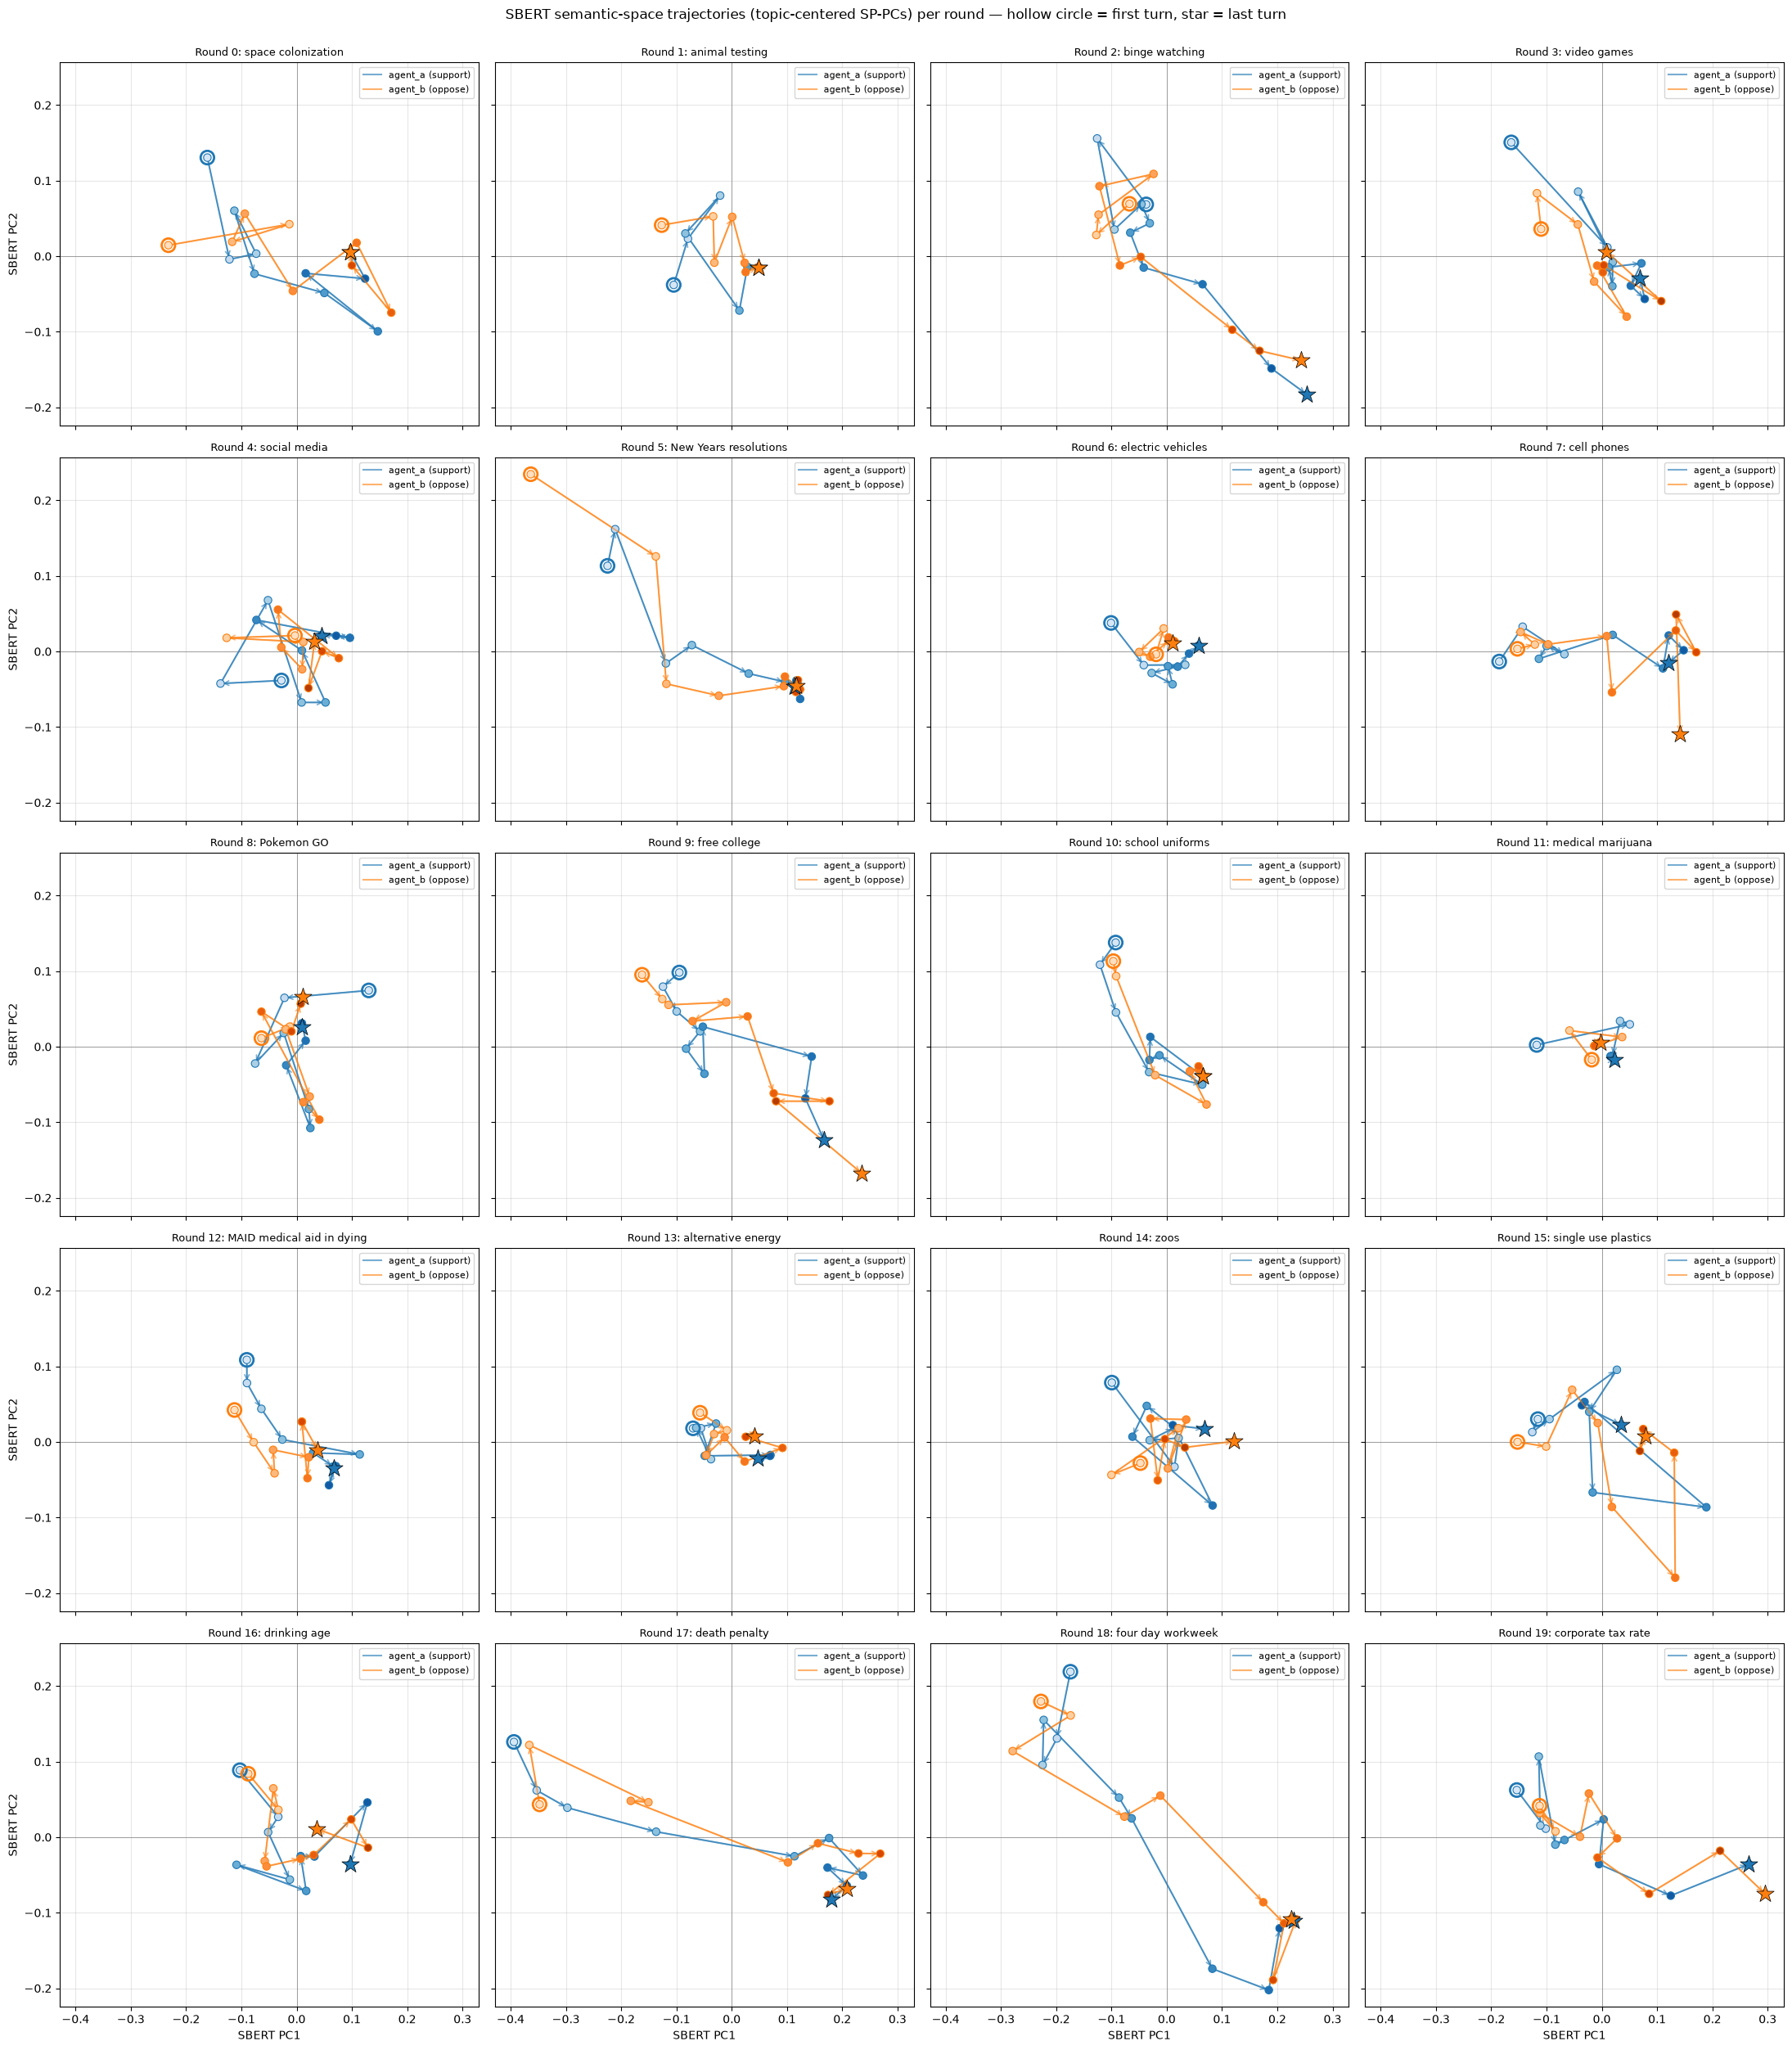

In [111]:
df = pd.read_json(Path(RUN_DIR) / "records_sbert.jsonl", lines=True)
df["round_id"] = df["round_id"].astype(str)
 
STANCE = {"agent_a": "support", "agent_b": "oppose"}
COLOR = {"agent_a": "tab:blue", "agent_b": "tab:orange"}
CMAP = {"agent_a": "Blues", "agent_b": "Oranges"}
 
rounds = sorted(df["round_id"].unique(), key=lambda r: int(r))
ncols = min(4, len(rounds))
nrows = -(-len(rounds) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows),
                         sharex=True, sharey=True, squeeze=False)
 
for ax, rnd in zip(axes.flat, rounds):
    sub = df[df["round_id"] == rnd]
    for speaker, grp in sub.groupby("speaker"):
        grp = grp.sort_values("turn")
        c = COLOR[speaker]
        x, y = grp["sbert_pc1"].values, grp["sbert_pc2"].values
 
        ax.plot(x, y, color=c, alpha=0.6, lw=1.5,
                label=f"{speaker} ({STANCE[speaker]})", zorder=2)
        for i in range(len(x) - 1):
            ax.annotate("", xy=(x[i + 1], y[i + 1]), xytext=(x[i], y[i]),
                        arrowprops=dict(arrowstyle="->", color=c, alpha=0.6, lw=1.2))
        ax.scatter(x, y, c=grp["turn"], cmap=CMAP[speaker],
                   vmin=-2, vmax=grp["turn"].max() + 1,
                   s=45, edgecolors=c, linewidths=0.8, zorder=3)
        ax.scatter(x[0], y[0], marker="o", s=140, facecolors="none",
                   edgecolors=c, linewidths=2, zorder=4)
        ax.scatter(x[-1], y[-1], marker="*", s=260, color=c,
                   edgecolors="k", linewidths=0.5, zorder=4)
 
    ax.set_title(f"Round {rnd}: {sub['topic'].iloc[0][:60]}", fontsize=9)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc="best")
 
for ax in axes.flat[len(rounds):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("SBERT PC1")
for row in axes:
    row[0].set_ylabel("SBERT PC2")
 
fig.suptitle("SBERT semantic-space trajectories (topic-centered SP-PCs) per round — "
             "hollow circle = first turn, star = last turn", y=1.0)
plt.tight_layout()
plt.show()


In [ ]:
MODEL_COLOR = {"qwen": "#7fc7ff", "gemma": "#ffb3c6"}   # light blue / light pink (endpoints)
TRAJ_COLOR  = {"qwen": "tab:blue", "gemma": "tab:pink"}  # trajectory lines

fig, ax = plt.subplots(figsize=(8, 8))

endpoints = []  # (x, y, model) for hull computation

for (model, rnd, speaker), grp in df.groupby(["model", "round_id", "speaker"]):
    grp = grp.sort_values("turn")
    x, y = grp["sbert_pc1"].values, grp["sbert_pc2"].values

    ax.plot(x, y, color=TRAJ_COLOR[model], alpha=0.2, lw=1, zorder=1)

    ax.scatter(x[-1], y[-1], color=MODEL_COLOR[model], s=80,
               edgecolors="k", linewidths=0.6, zorder=3)
    endpoints.append((x[-1], y[-1], model))

endpoints = pd.DataFrame(endpoints, columns=["x", "y", "model"])

for model, sub in endpoints.groupby("model"):
    pts = sub[["x", "y"]].values
    if len(pts) >= 3:
        hull = ConvexHull(pts)
        hull_pts = np.vstack([pts[hull.vertices], pts[hull.vertices[0]]])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1], color=MODEL_COLOR[model],
                lw=2, linestyle="--", label=f"{model} endpoint hull")
        ax.fill(hull_pts[:, 0], hull_pts[:, 1], color=MODEL_COLOR[model], alpha=0.15)

ax.set_xlabel("SBERT PC1")
ax.set_ylabel("SBERT PC2")
ax.set_title("Persona-drift trajectories in SBERT PCA space")
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.legend(fontsize=9, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
